# Fourier Neural Operator (FNO) for Coupled ODE Systems

This notebook demonstrates the implementation of a **Fourier Neural Operator (FNO)** to learn the solution operator for a coupled concentration-temperature system. Unlike traditional solvers, the FNO learns to map initial conditions and physical parameters directly to the full solution trajectory in frequency space.

Physical context: Use a Fourier Neural Operator to learn the solution operator for the coupled concentration-temperature system from Problem 3 of your PINN series. The FNO maps initial conditions and parameters to full solution trajectories.
Operator to learn:
G: [C₀, T₀, cool_coef] → [C(t), T(t)]
Input:  3-element parameter vector
Output: two solution trajectories over t ∈ [0, 10]
Training data generation:
Sample 500 combinations of initial conditions and parameters:
pythonC0_samples       = np.random.uniform(0.5, 1.5, 500)
T0_samples       = np.random.uniform(330, 370, 500)
cool_coef_samples = np.random.uniform(0.02, 0.10, 500)
For each combination, solve the coupled ODE system numerically using solve_ivp. This gives 500 input-output pairs where the output is a (2, 100) array — both C(t) and T(t) at 100 time points.

Step-1: The Spectral Convolutional Layer

### 1.1 The Spectral Convolutional Layer
The core of the FNO is the spectral convolution, which performs a linear transformation in the Fourier domain, effectively acting as a global operator.

This is the heart of FNO. It is a convolution operation performed in frequency space.

In [12]:
# importing libraries
import torch
import torch.nn as nn


# Defining the Spectral Convolutional layer
class SpectralConv1d(nn.Module):
  def __init__(self, in_channels, out_channels, n_modes):
    super().__init__()
    # in_channels:    Number of input channels (e.g. 64)
    # out_channels:   Number of output channels (e.g. 64)
    # n_modes:        how many frequency modes to keep (e.g. 16)

    self.in_channels = in_channels
    self.out_channels = out_channels
    self.n_modes = n_modes

    # The learnable parameters are complex weights in frequency space.
    # Shape: (in_channels, out_channels, n_modes)
    # We store real and imaginary parts separately because Pytorch
    # nn.Parameter does not support complex parameters directly

    scale = 1.0 / (in_channels * out_channels)
    self.weights_real = nn.Parameter(scale * torch.randn(in_channels, out_channels, n_modes))
    self.weights_img = nn.Parameter(scale * torch.randn(in_channels, out_channels, n_modes))

    # Why scale by 1 / (in*out) ? To prevent initial outputs from being
    # too large, which would destabilise training. Same idea as
    # Glorot initialization in PINNs.

  def forward(self, x):
    # x shape: (bathc, in_channes, n_points)
    batch, in_ch, n_pts = x.shape

    # Step A: Go to frequency space
    x_ft = torch.fft.rfft(x, dim=-1)
    # rfft operates on the last dimension (n_points)
    # Output shape: (batch, in_channels, n_pts//2 + 1)
    # Each element is a complex number: real + j * img
    # The n_pts // 2 + 1 comes from rfft symmetry reduction.

    # Step B: Spectral convolution
    # Combine real and imag into one complex weight tensor
    weights = torch.complex(self.weights_real, self.weights_img)
    # weights shape: (in_channels, out_channels, n_modes)

    # Create output frequency tensor, initialized to zero
    out_ft = torch.zeros(
        batch, self.out_channels, n_pts // 2 + 1, dtype=torch.cfloat,
        device=x.device
    )

    # Multiply the first n_modes frequency components by the learned weights.
    # This is the "convolution in frequency space" — multiplying two signals'
    # Fourier transforms is equivalent to convolving them in physical space.
    #
    # Einstein summation: 'bim, iom -> bom'
    #   b = batch dimension
    #   i = input channels
    #   m = frequency modes
    #   o = output channels
    # For each sample and each frequency mode, mix input channels into output.
    out_ft[:, :, :self.n_modes] = torch.einsum(
        'bim, iom -> bom', x_ft[:, :, :self.n_modes], weights
    )

    # Frequencies beyond n_modes stay zero — they are discarded.
    # This is the low-pass filtering effect of FNO
    # ── Step C: Back to physical space ─────────────────────────────
    x_out = torch.fft.irfft(out_ft, n=n_pts, dim=-1)
    # irfft inverts the rfft. We pass n=n_pts to get back exactly
    # n_pts points (otherwise it might give n_pts-1 due to rounding).
    # Output shape: (batch, out_channels, n_points) — real value
    return x_out

Step 2 — One FNO Layer

### 1.2 The FNO Layer
A single FNO layer combines the spectral convolution with a local skip connection (1x1 convolution) to capture both global and local features.

Each FNO layer has two parallel paths that are added together. This is the key architectural insight:

In [13]:
class FNOLayer1d(nn.Module):
  def __init__(self, channels, n_modes):
    super().__init__()
    self.spectral = SpectralConv1d(channels, channels, n_modes)
    self.pointwise = nn.Conv1d(channels, channels, kernel_size = 1)
    self.activation = nn.GELU()

  def forward(self, x):
    x1 = self.spectral(x)
    x2 = self.pointwise(x)
    return self.activation(x1 + x2)

Step 3 — Full FNO Model

### 1.3 The Full FNO Architecture
The model lifts the input to a higher-dimensional latent space, applies multiple FNO layers, and projects back to the target output dimension.

In [14]:
class FNO1d(nn.Module):
  def __init__(self, in_channels, out_channels, n_modes, width, n_layers=4):
    super().__init__()
    self.input_lift = nn.Linear(in_channels, width)
    self.fno_layers = nn.ModuleList([
        FNOLayer1d(width, n_modes) for _ in range(n_layers)
    ])
    self.output_proj = nn.Sequential(
        nn.Linear(width, 128),
        nn.GELU(),
        nn.Linear(128, out_channels)
    )

  def forward(self, x):
    x = self.input_lift(x)
    x = x.permute(0, 2, 1)
    for layer in self.fno_layers:
      x = layer(x)
    x = x.permute(0, 2, 1)
    x = self.output_proj(x)
    return x

Data Generation for Problem 4

## 2. Data Generation
We generate training data by solving the coupled ODE system using `solve_ivp` for various initial concentrations, temperatures, and cooling coefficients.

In [15]:
from scipy.integrate import solve_ivp
import numpy as np
import torch

# Physical parameters (same as PINN problem 3)
A0 = 5e5
Ea = 60000.0
R = 8.314
delH = -40000.0
rhocp = 4000.0

def coupled_ode(t, y, cool_coef):
  C, T = y
  k = A0 * np.exp(-Ea / (R*T))
  rate = k*C
  dCdt = -rate
  dTdt = (-delH / rhocp) * rate - cool_coef * (T - 350.0)
  return [dCdt, dTdt]

def generate_data(n_samples, n_points = 100, t_max = 2.0):
  np.random.seed(42)
  t_grid = np.linspace(0, t_max, n_points)

  # Sample random initial conditions and parameters
  C0_samples = np.random.uniform(0.5, 1.5, n_samples)
  T0_samples = np.random.uniform(330, 370, n_samples)
  cool_coef_samples = np.random.uniform(0.02, 0.10, n_samples)

  X_data = []   # inputs - shape (n_samples, n_points, 4)
  Y_data = []   # outputs - Shape (n_samples, n_points, 2)

  for i in range(n_samples):
    C0 = C0_samples[i]
    T0 = T0_samples[i]
    cc = cool_coef_samples[i]

    sol = solve_ivp(
        coupled_ode, [0, t_max], [C0, T0],
        t_eval = t_grid, args=(cc,),
        method='RK45', rtol=1e-8, atol=1e-10
    )

    # Output: C(t) and T(t) on grid
    C_traj = sol.y[0]  # shape (n_points, )
    T_traj = sol.y[1]  # shape (n_points, )

    # Input: Broadcast parameters + time coordinate
    t_norm = t_grid / t_max
    input_func = np.stack([
        np.full(n_points, C0),
        np.full(n_points, T0/400),
        np.full(n_points, cc),
        t_norm
    ], axis=1)

    # Normalize outputs
    C_norm = C_traj / 1.5
    T_norm = (T_traj - 330) / 40
    output_func = np.stack([C_norm, T_norm], axis = -1)

    X_data.append(input_func)
    Y_data.append(output_func)

  X = torch.tensor(np.array(X_data), dtype=torch.float32)
  Y = torch.tensor(np.array(Y_data), dtype=torch.float32)
  return X, Y

## 3. Training the Model
We train the FNO using a weighted Mean Squared Error (MSE) loss to ensure the model accurately captures both concentration ($C$) and temperature ($T$) dynamics.

In [16]:
# Generate data
X_train, Y_train = generate_data(n_samples=500, n_points=100)
X_test,  Y_test  = generate_data(n_samples=100, n_points=100)

# Build model
model = FNO1d(
    in_channels  = 4,
    out_channels = 2,
    n_modes      = 16,
    width        = 64,
    n_layers     = 4
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9997)

from torch.utils.data import TensorDataset, DataLoader
dataset    = TensorDataset(X_train, Y_train)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Define loss weights
# Increase weight for C (index 0) to capture subtler dynamics
w_c = 5.0
w_t = 1.0

for epoch in range(1001):
    model.train()
    total_loss = 0
    for X_batch, Y_batch in dataloader:
        optimizer.zero_grad()
        Y_pred = model(X_batch)

        # Weighted MSE Loss
        loss_c = torch.mean((Y_pred[:, :, 0] - Y_batch[:, :, 0])**2)
        loss_t = torch.mean((Y_pred[:, :, 1] - Y_batch[:, :, 1])**2)
        loss = w_c * loss_c + w_t * loss_t

        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    if epoch % 50 == 0:
        model.eval()
        with torch.no_grad():
            Y_pred_test = model(X_test)
            test_loss_c = torch.mean((Y_pred_test[:, :, 0] - Y_test[:, :, 0])**2).item()
            test_loss_t = torch.mean((Y_pred_test[:, :, 1] - Y_test[:, :, 1])**2).item()
            test_loss = w_c * test_loss_c + w_t * test_loss_t
        print(f"Epoch {epoch:4d} | Weighted Loss: {total_loss/len(dataloader):.4e} | C-MSE: {test_loss_c:.4e} | T-MSE: {test_loss_t:.4e}")

Epoch    0 | Weighted Loss: 1.3109e+00 | C-MSE: 5.9642e-02 | T-MSE: 1.0113e-01
Epoch   50 | Weighted Loss: 3.7435e-04 | C-MSE: 3.4276e-06 | T-MSE: 2.3953e-04
Epoch  100 | Weighted Loss: 1.2833e-04 | C-MSE: 8.0754e-07 | T-MSE: 6.4403e-05
Epoch  150 | Weighted Loss: 6.3579e-05 | C-MSE: 5.2208e-07 | T-MSE: 6.2079e-05
Epoch  200 | Weighted Loss: 1.3668e-04 | C-MSE: 4.2941e-07 | T-MSE: 6.2314e-05
Epoch  250 | Weighted Loss: 9.8299e-05 | C-MSE: 7.0618e-07 | T-MSE: 1.9255e-04
Epoch  300 | Weighted Loss: 5.2046e-05 | C-MSE: 5.3907e-07 | T-MSE: 4.9895e-05
Epoch  350 | Weighted Loss: 4.5597e-05 | C-MSE: 5.3907e-07 | T-MSE: 4.4221e-05
Epoch  400 | Weighted Loss: 4.8715e-05 | C-MSE: 4.2654e-07 | T-MSE: 1.1590e-04
Epoch  450 | Weighted Loss: 3.8685e-05 | C-MSE: 2.4773e-07 | T-MSE: 3.2881e-05
Epoch  500 | Weighted Loss: 4.2701e-05 | C-MSE: 2.1603e-07 | T-MSE: 3.1291e-05
Epoch  550 | Weighted Loss: 3.4674e-05 | C-MSE: 1.8577e-06 | T-MSE: 3.3003e-05
Epoch  600 | Weighted Loss: 3.0441e-05 | C-MSE: 3.52

## 4. Evaluation and Visualization
Finally, we evaluate the model on unseen test data and visualize the predicted trajectories against the ground truth numerical solutions.

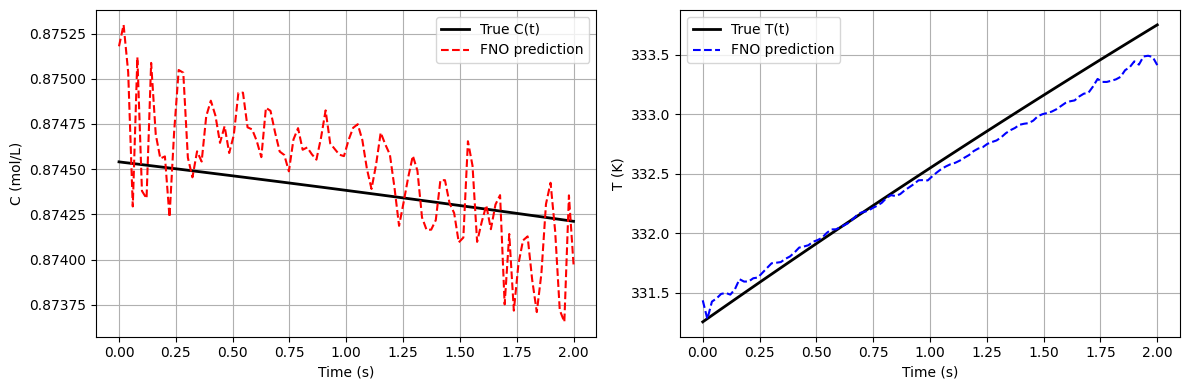

C Rel L2: 0.0329%
T Rel L2: 0.0389%


In [17]:
model.eval()
with torch.no_grad():
    # Pick one unseen test sample
    idx = 0
    X_sample = X_test[idx:idx+1]   # (1, n_points, 4)
    Y_pred   = model(X_sample).squeeze().numpy()   # (n_points, 2)
    Y_true   = Y_test[idx].numpy()                 # (n_points, 2)

    # Define t_grid globally for plotting
    # Using 100 points over 2.0 seconds to match generate_data defaults
    t_grid = np.linspace(0, 2.0, 100)

    # Unscale
    C_pred = Y_pred[:, 0] * 1.5
    T_pred = Y_pred[:, 1] * 40 + 330
    C_true = Y_true[:, 0] * 1.5
    T_true = Y_true[:, 1] * 40 + 330

    import matplotlib.pyplot as plt
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(t_grid, C_true, 'k-', lw=2, label='True C(t)')
    ax1.plot(t_grid, C_pred, 'r--', lw=1.5, label='FNO prediction')
    ax1.set_xlabel('Time (s)'); ax1.set_ylabel('C (mol/L)')
    ax1.legend(); ax1.grid(True)

    ax2.plot(t_grid, T_true, 'k-', lw=2, label='True T(t)')
    ax2.plot(t_grid, T_pred, 'b--', lw=1.5, label='FNO prediction')
    ax2.set_xlabel('Time (s)'); ax2.set_ylabel('T (K)')
    ax2.legend(); ax2.grid(True)
    plt.tight_layout(); plt.show()

    # Error
    rel_l2_C = np.linalg.norm(C_pred - C_true) / np.linalg.norm(C_true)
    rel_l2_T = np.linalg.norm(T_pred - T_true) / np.linalg.norm(T_true)
    print(f"C Rel L2: {rel_l2_C*100:.4f}%")
    print(f"T Rel L2: {rel_l2_T*100:.4f}%")

In [18]:
model.eval()
with torch.no_grad():
    Y_pred_all = model(X_test)

    # Unscale
    C_pred_all = Y_pred_all[:, :, 0] * 1.5
    T_pred_all = Y_pred_all[:, :, 1] * 40 + 330
    C_true_all = Y_test[:, :, 0] * 1.5
    T_true_all = Y_test[:, :, 1] * 40 + 330

    # Rel L2 across all 100 test samples
    rel_l2_C = (torch.norm(C_pred_all - C_true_all, dim=1) /
                torch.norm(C_true_all, dim=1)).mean().item()
    rel_l2_T = (torch.norm(T_pred_all - T_true_all, dim=1) /
                torch.norm(T_true_all, dim=1)).mean().item()

    print(f"Mean C Rel L2 over 100 test samples: {rel_l2_C*100:.4f}%")
    print(f"Mean T Rel L2 over 100 test samples: {rel_l2_T*100:.4f}%")

Mean C Rel L2 over 100 test samples: 0.0496%
Mean T Rel L2 over 100 test samples: 0.0415%
